In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [77]:
df=pd.read_csv("/content/Electronic_sales_Sep2023-Sep2024.csv")

In [78]:
df.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


In [79]:
df.describe(include="all")

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
count,20000.000000,20000.000000,19999,20000,20000,20000,20000.000000,20000,20000,20000.000000,20000.000000,20000.000000,20000,20000,15132,20000.000000
unique,NaN,NaN,2,2,5,10,NaN,2,6,NaN,NaN,NaN,366,5,75,NaN
top,NaN,NaN,Male,No,Smartphone,TBL345,NaN,Completed,Credit Card,NaN,NaN,NaN,2024-04-26,Standard,Extended Warranty,NaN
freq,NaN,NaN,10164,15657,5978,2062,NaN,13432,5868,NaN,NaN,NaN,88,6725,1701,NaN
mean,10483.526550,48.994100,NaN,NaN,NaN,NaN,3.093950,NaN,NaN,3180.133419,578.631867,5.485550,NaN,NaN,NaN,62.244848
std,5631.732525,18.038745,NaN,NaN,NaN,NaN,1.223764,NaN,NaN,2544.978675,312.274076,2.870854,NaN,NaN,NaN,58.058431
min,1000.000000,18.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,20.750000,20.750000,1.000000,NaN,NaN,NaN,0.000000
25%,5478.000000,33.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,1139.680000,361.180000,3.000000,NaN,NaN,NaN,7.615000
50%,10499.500000,49.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,2534.490000,463.960000,5.000000,NaN,NaN,NaN,51.700000
75%,15504.000000,65.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,4639.600000,791.190000,8.000000,NaN,NaN,NaN,93.842500


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        20000 non-null  int64  
 1   Age                20000 non-null  int64  
 2   Gender             19999 non-null  object 
 3   Loyalty Member     20000 non-null  object 
 4   Product Type       20000 non-null  object 
 5   SKU                20000 non-null  object 
 6   Rating             20000 non-null  int64  
 7   Order Status       20000 non-null  object 
 8   Payment Method     20000 non-null  object 
 9   Total Price        20000 non-null  float64
 10  Unit Price         20000 non-null  float64
 11  Quantity           20000 non-null  int64  
 12  Purchase Date      20000 non-null  object 
 13  Shipping Type      20000 non-null  object 
 14  Add-ons Purchased  15132 non-null  object 
 15  Add-on Total       20000 non-null  float64
dtypes: float64(3), int64(4

In [81]:
df['Purchase Date']=pd.to_datetime(df['Purchase Date'])

In [82]:
df.dtypes

,0
Customer ID,int64
Age,int64
Gender,object
Loyalty Member,object
Product Type,object
SKU,object
Rating,int64
Order Status,object
Payment Method,object
Total Price,float64


In [83]:
df.nunique()

,0
Customer ID,12136
Age,63
Gender,2
Loyalty Member,2
Product Type,5
SKU,10
Rating,5
Order Status,2
Payment Method,6
Total Price,104


In [84]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,1
Loyalty Member,0
Product Type,0
SKU,0
Rating,0
Order Status,0
Payment Method,0
Total Price,0


In [85]:
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix)

,Customer ID,Age,Rating,Total Price,Unit Price,Quantity,Add-on Total
Customer ID,1.000000,-0.013297,-0.076836,0.203207,0.297445,0.010464,0.317418
Age,-0.013297,1.000000,0.002949,0.003096,-0.004402,0.008555,-0.005291
Rating,-0.076836,0.002949,1.000000,-0.232429,-0.343829,-0.008587,-0.044338
Total Price,0.203207,0.003096,-0.232429,1.000000,0.673951,0.653872,0.083924
Unit Price,0.297445,-0.004402,-0.343829,0.673951,1.000000,0.006715,0.125189
Quantity,0.010464,0.008555,-0.008587,0.653872,0.006715,1.000000,0.003419
Add-on Total,0.317418,-0.005291,-0.044338,0.083924,0.125189,0.003419,1.000000


In [86]:
df['Purchase Year'] = df['Purchase Date'].dt.year
df['Purchase Month'] = df['Purchase Date'].dt.month

display(df[['Purchase Date', 'Purchase Year', 'Purchase Month']].head())

,Purchase Date,Purchase Year,Purchase Month
0,2024-03-20,2024,3
1,2024-04-20,2024,4
2,2023-10-17,2023,10
3,2024-08-09,2024,8
4,2024-05-21,2024,5


In [87]:
Product_type_count = df['Product Type'].value_counts()
display(Product_type_count)

,count
Product Type,
Smartphone,5978
Tablet,4104
Laptop,3973
Smartwatch,3934
Headphones,2011


In [88]:
sku_by_product_type = df.groupby('Product Type')['SKU'].unique()
display(sku_by_product_type)

,SKU
Product Type,
Headphones,"[SKU1003, HDP456]"
Laptop,"[SKU1005, SKU1004, LTP123]"
Smartphone,"[SKU1004, SKU1001, SKU1005, SMP234]"
Smartwatch,"[SKU1003, SWT567]"
Tablet,"[SKU1002, TBL345]"


In a dataset, SKU stands for Stock Keeping Unit. It is a unique alphanumeric code used by businesses to internally identify and track individual products or specific product variations (such as a specific size, color, or model)

In [89]:
rating_by_prod_type=df.groupby('Product Type')['Rating'].unique()
display(rating_by_prod_type)

,Rating
Product Type,
Headphones,"[1, 3, 4, 2, 5]"
Laptop,"[3, 4, 1, 5, 2]"
Smartphone,"[2, 5, 4, 1, 3]"
Smartwatch,"[3, 4, 5, 1, 2]"
Tablet,"[3, 2, 4, 1, 5]"


In [90]:
highest_rated_product_type = df.groupby('Product Type')['Rating'].max().idxmax()
max_rating_value = df.groupby('Product Type')['Rating'].max().max()

print(f"The product type with the highest rating is '{highest_rated_product_type}' with a maximum rating of {max_rating_value}.")

The product type with the highest rating is 'Headphones' with a maximum rating of 5.


In [91]:
five_star_ratings_df = df[df['Rating'] == 5]
product_five_star_counts = five_star_ratings_df['Product Type'].value_counts()
display(product_five_star_counts)

,count
Product Type,
Smartphone,2352
Tablet,435
Headphones,405
Smartwatch,396
Laptop,381


The product type that received a 5-star rating the most number of times is 'Smartphone' with 2352 occurrences.


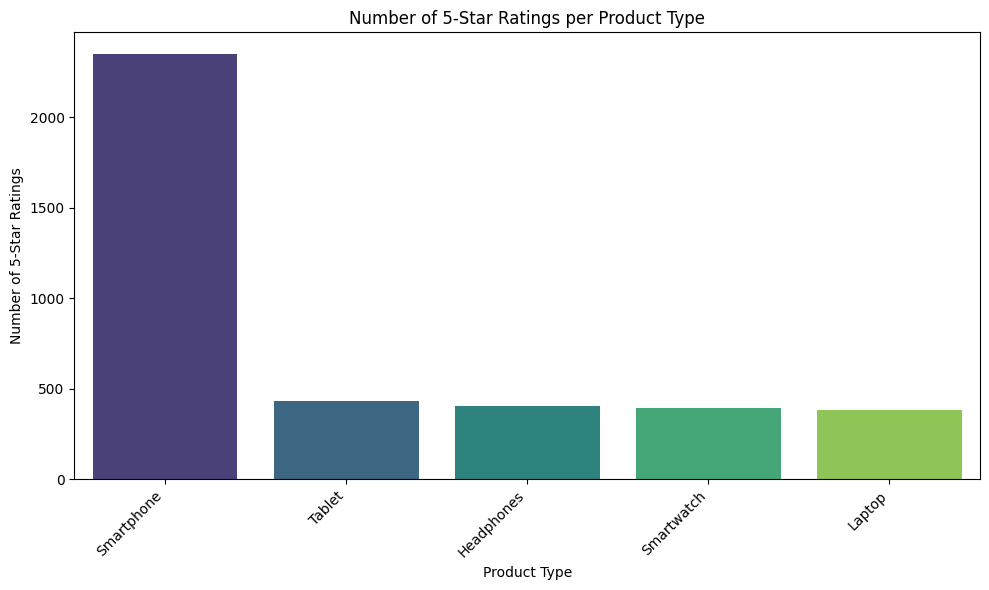

In [92]:
most_frequent_five_star_product = product_five_star_counts.idxmax()
count_of_five_star_ratings = product_five_star_counts.max()

print(f"The product type that received a 5-star rating the most number of times is '{most_frequent_five_star_product}' with {count_of_five_star_ratings} occurrences.")

plt.figure(figsize=(10, 6))
sns.barplot(x=product_five_star_counts.index, y=product_five_star_counts.values, palette='viridis', hue=product_five_star_counts.index, legend=False)
plt.title('Number of 5-Star Ratings per Product Type')
plt.xlabel('Product Type')
plt.ylabel('Number of 5-Star Ratings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [93]:
loyalty_member_count = df['Loyalty Member'].value_counts()
display(loyalty_member_count)

,count
Loyalty Member,
No,15657
Yes,4343


In [94]:
loyal_cancelled_count = df[(df['Loyalty Member'] == 'Yes') & (df['Order Status'] == 'Cancelled')].shape[0]
print(f"Number of loyalty members with cancelled orders: {loyal_cancelled_count}")

Number of loyalty members with cancelled orders: 1423




*  Out of 20,000 total customers, 15,657 customers (78.29%) are non-Loyalty Members, while 4,343 customers (21.72%) are Loyalty Members.
*  customers (78.29%) are non-Loyalty Members, while 4,343 customers (21.72%) are Loyalty Members.  
*  Among the 4,343 Loyalty Members, 1,423 customers (32.76%) have cancelled their orders.
The remaining 2,920 Loyalty Members (67.24%) have not cancelled their orders.

Since Loyalty Members represent a valuable customer segment, it would be beneficial to collect reviews and feedback from them to better understand the reasons behind order cancellations and identify the services, benefits, or improvements they expect from us.
The insights gathered can help us improve customer experience, strengthen loyalty, and reduce future order cancellations among Loyalty Members.




Gender
Male      10164
Female     9835
Name: count, dtype: int64


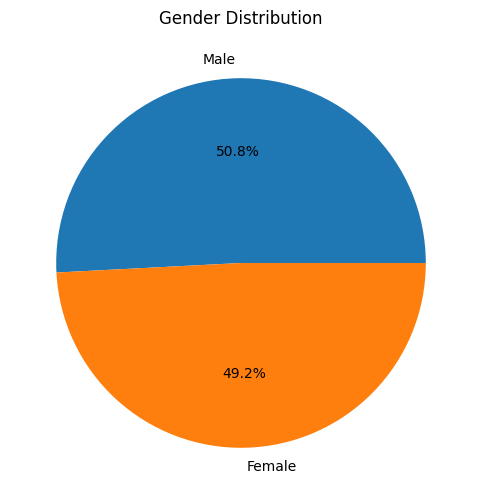

In [95]:
gender_count=df['Gender'].value_counts()
print(gender_count)

df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6))
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

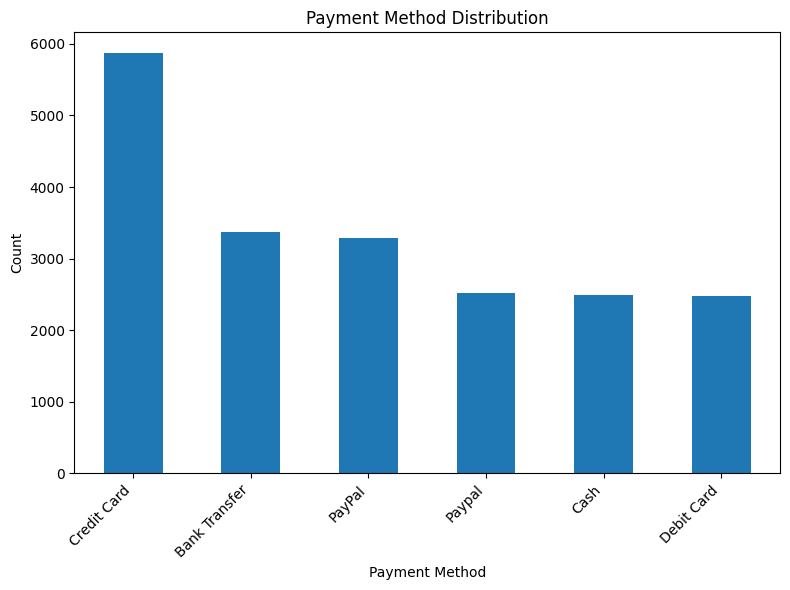

In [96]:
df['Payment Method'].value_counts().plot(kind='bar', figsize=(8, 6))
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
#Here we can observe that both 'Paypal' and 'PayPal' are same attribute but decoded as different so we will combine both to get one similar feature.

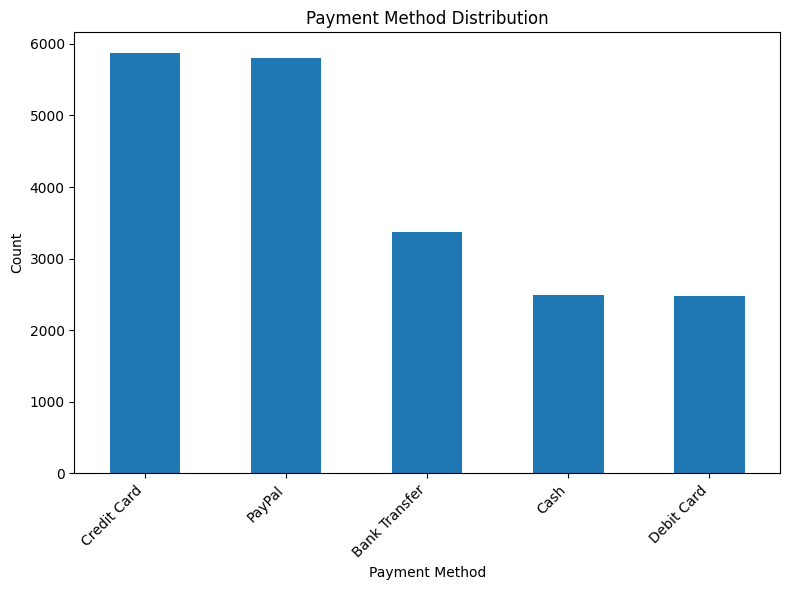

In [97]:
df['Payment Method'] = df['Payment Method'].replace('Paypal', 'PayPal')
df['Payment Method'].value_counts().plot(kind='bar', figsize=(8, 6))
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



*   By combining both analyses, we gain a clearer and more comprehensive view of customer payment behavior and preferences.
*   To encourage higher cash transactions, we can offer targeted discounts, special deals, or instant savings to customers who choose cash payments.
*   At the same time, we can provide rewards, cashback offers, or loyalty incentives for customers using digital payment methods such as credit cards and PayPal.
* This balanced approach can help increase both cash and digital transactions while enhancing customer satisfaction and driving overall sales growth.



In [98]:
# Fill NaN values in 'Add-ons Purchased' with an empty string for easier processing
df['Add-ons Purchased'] = df['Add-ons Purchased'].fillna('')

# Group by 'Product Type' and aggregate 'Add-ons Purchased'
# We need to split the strings and get unique add-ons for each product type
product_addons = df.groupby('Product Type')['Add-ons Purchased'].apply(
    lambda x: sorted(list(set(','.join(x).replace(' ', '').split(',')) - {''}))
)

display(product_addons)

,Add-ons Purchased
Product Type,
Headphones,"[Accessory, ExtendedWarranty, ImpulseItem]"
Laptop,"[Accessory, ExtendedWarranty, ImpulseItem]"
Smartphone,"[Accessory, ExtendedWarranty, ImpulseItem]"
Smartwatch,"[Accessory, ExtendedWarranty, ImpulseItem]"
Tablet,"[Accessory, ExtendedWarranty, ImpulseItem]"


In [99]:
# Create a temporary DataFrame for add-on analysis to avoid modifying the original 'Add-ons Purchased' column structure
addons_df = df[['Product Type', 'Add-ons Purchased']].copy()

# Split the 'Add-ons Purchased' string into a list of add-ons
# and then explode the list into separate rows
addons_df['Individual Add-on'] = addons_df['Add-ons Purchased'].str.split(',')
exploded_addons = addons_df.explode('Individual Add-on')

# Clean up any leading/trailing spaces and filter out empty strings
exploded_addons['Individual Add-on'] = exploded_addons['Individual Add-on'].str.strip()
exploded_addons = exploded_addons[exploded_addons['Individual Add-on'] != '']

# Group by 'Product Type' and 'Individual Add-on' and count the frequencies
addon_frequencies_by_product = exploded_addons.groupby(['Product Type', 'Individual Add-on']).size().reset_index(name='Frequency')

display(addon_frequencies_by_product.sort_values(by=['Product Type', 'Frequency'], ascending=[True, False]))

,Product Type,Individual Add-on,Frequency
2,Headphones,Impulse Item,1068
0,Headphones,Accessory,1016
1,Headphones,Extended Warranty,1000
5,Laptop,Impulse Item,2077
4,Laptop,Extended Warranty,1998
3,Laptop,Accessory,1971
6,Smartphone,Accessory,3041
7,Smartphone,Extended Warranty,2995
8,Smartphone,Impulse Item,2974
11,Smartwatch,Impulse Item,2013


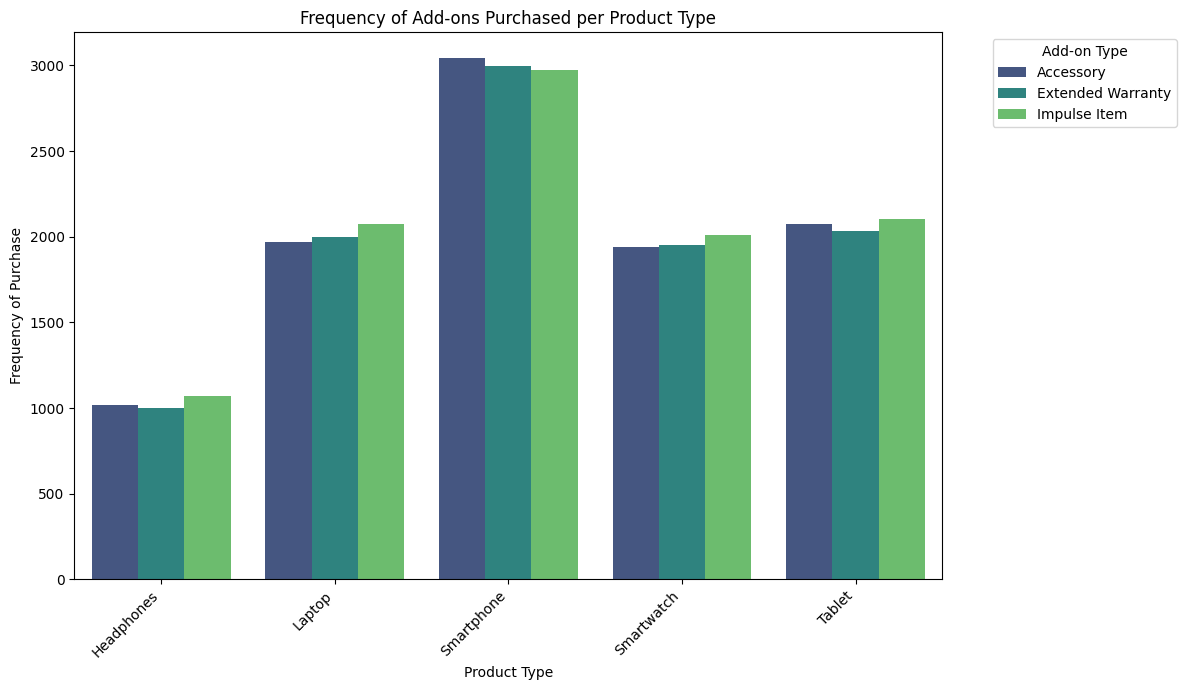

In [100]:
plt.figure(figsize=(12, 7))
sns.barplot(data=addon_frequencies_by_product, x='Product Type', y='Frequency', hue='Individual Add-on', palette='viridis')
plt.title('Frequency of Add-ons Purchased per Product Type')
plt.xlabel('Product Type')
plt.ylabel('Frequency of Purchase')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Add-on Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


*  The analysis shows that smartphone customers are the most likely to purchase add-ons, including accessories, extended warranties, and impulse items. Therefore, smartphone buyers should be the primary target for cross-selling and promotional campaigns. We can provide offers and discounts on add-ons purchases, especially who purchase smartphones.

*  We can introduce **bundle offers, discounts, and special promotions on accessories and add-on products** for smartphone customers to increase the average order value and overall sales.

*  Since **tablets and laptops also demonstrate strong add-on purchase behavior**, similar promotional strategies can be applied to these product categories to maximize revenue opportunities.

*  Based on the add-on purchase patterns, **accessories, extended warranties, and impulse-buy products should be strategically displayed near smartphones, tablets, and laptops**, both in physical stores and on e-commerce product pages.

*   This approach can improve product visibility, encourage impulse purchases, and increase the likelihood of customers purchasing complementary products alongside their main purchase.


*  By leveraging these insights, we can enhance cross-selling opportunities, improve the customer shopping experience, and drive higher overall revenue.










#### Monthly Sales Analysis

The month with the highest sales is Month 5 with total sales of $6709042.93.


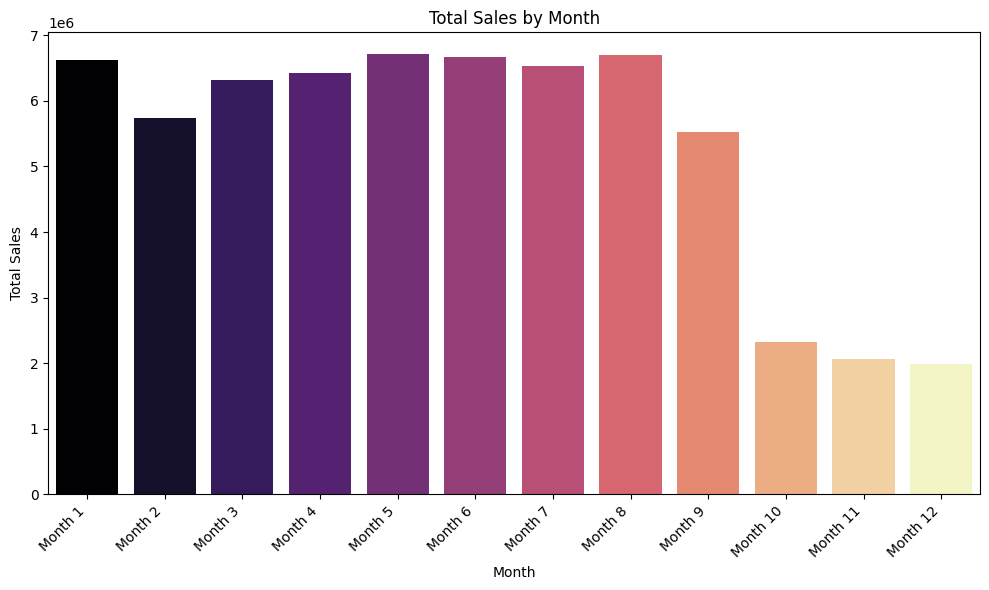

In [101]:
monthly_sales = df.groupby('Purchase Month')['Total Price'].sum().reset_index()

highest_sales_month = monthly_sales.loc[monthly_sales['Total Price'].idxmax()]
print(f"The month with the highest sales is Month {int(highest_sales_month['Purchase Month'])} with total sales of ${highest_sales_month['Total Price']:.2f}.")

plt.figure(figsize=(10, 6))
sns.barplot(x='Purchase Month', y='Total Price', data=monthly_sales, palette='magma', hue='Purchase Month', legend=False)
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(ticks=range(0, 12), labels=[f'Month {i+1}' for i in range(12)], rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Yearly Sales Analysis

The year with the highest sales is 2024 with total sales of $56753105.76.


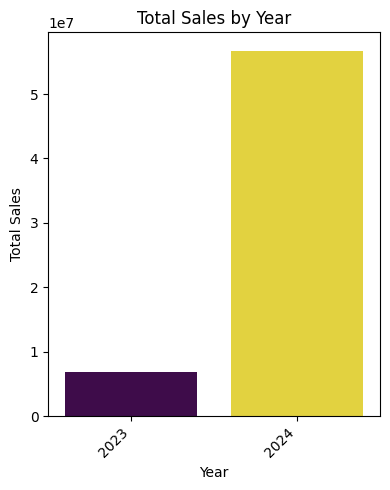

In [102]:
yearly_sales = df.groupby('Purchase Year')['Total Price'].sum().reset_index()

highest_sales_year = yearly_sales.loc[yearly_sales['Total Price'].idxmax()]
print(f"The year with the highest sales is {int(highest_sales_year['Purchase Year'])} with total sales of ${highest_sales_year['Total Price']:.2f}.")

plt.figure(figsize=(4, 5))
sns.barplot(x='Purchase Year', y='Total Price', data=yearly_sales, palette='viridis', hue='Purchase Year', legend=False)
plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [103]:
Total_Price_count=df['Total Price'].mean()
print(Total_Price_count)

3180.1334185


In [104]:
print(f"Total Price: {df['Total Price'].sum():.2f}")
print(f"Mean Total Price: {df['Total Price'].mean():.2f}")
print(f"Max Total Price: {df['Total Price'].max():.2f}")
print(f"Min Total Price: {df['Total Price'].min():.2f}")
print(f"Median Total Price: {df['Total Price'].median():.2f}")

Total Price: 63602668.37
Mean Total Price: 3180.13
Max Total Price: 11396.80
Min Total Price: 20.75
Median Total Price: 2534.49


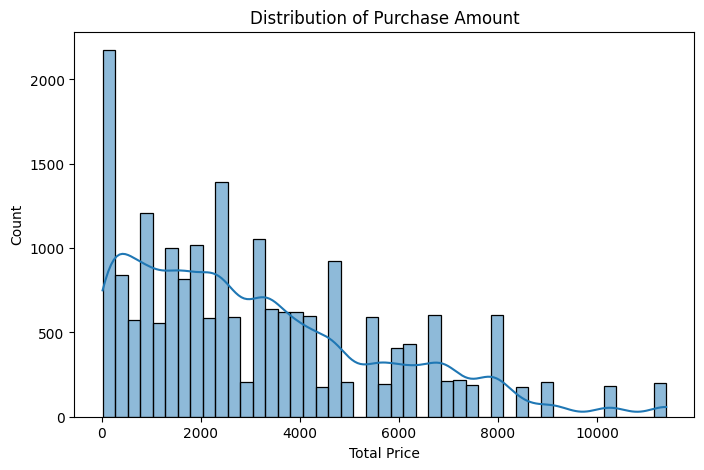

In [105]:
plt.figure(figsize=(8,5))
sns.histplot(df["Total Price"], kde=True)
plt.title("Distribution of Purchase Amount")
plt.show()

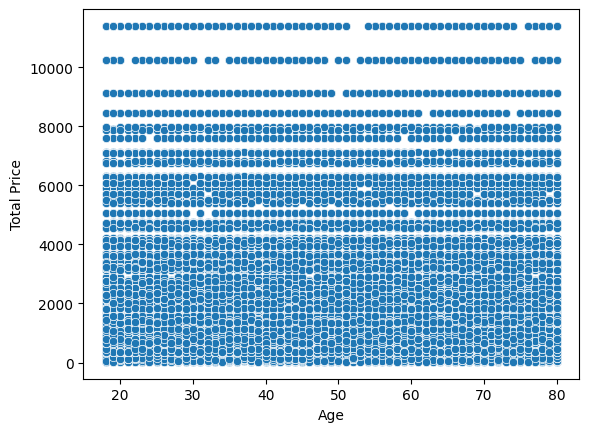

In [106]:
sns.scatterplot(x="Age", y="Total Price", data=df)
plt.show()


## Comprehensive Conclusion and Key Insights from Electronic Sales Data Analysis

This Colab notebook provided a thorough exploratory data analysis of the electronic sales dataset, covering aspects from data overview and cleaning to identifying sales trends, customer behavior, and product performance. Below is a summary of the key findings and actionable recommendations:

### 1. Data Overview and Preparation
*   **Data Integrity**: The dataset contained detailed information on customer demographics, product types, sales metrics, and purchase details. Initial checks confirmed data types and identified missing values, particularly in the 'Gender' (1 NaN) and 'Add-ons Purchased' (4868 NaNs) columns.
*   **Date Transformation**: 'Purchase Date' was successfully converted to datetime objects, and new 'Purchase Year' and 'Purchase Month' columns were extracted for time-series analysis.
*   **Data Standardization**: Inconsistent 'Payment Method' entries ('Paypal' and 'PayPal') were standardized to 'PayPal' for accurate analysis.

### 2. Product Performance and Customer Satisfaction
*   **Highest Rated Products**: While 'Headphones' had a maximum rating of 5, 'Smartphone' was the product type that received the most 5-star ratings (2352 occurrences), indicating strong customer satisfaction within this category. This was visualized through bar plots.
*   **SKU vs. Product Type**: It was observed that 'SKU' and 'Product Type' are distinct entities, with 'SKU' representing specific product variations within a broader 'Product Type'.

### 3. Loyalty and Order Behavior
*   **Loyalty Member Analysis**: Approximately 21.72% of customers are Loyalty Members. A significant finding was that 1,423 (32.76%) of Loyalty Members had cancelled orders. This highlighted a critical area for improvement.
*   **Recommendation**: To reduce cancellations among Loyalty Members, it is crucial to collect feedback and understand their pain points. Addressing these can enhance customer experience, strengthen loyalty, and improve retention.

### 4. Payment Method Preferences
*   **Distribution**: 'Credit Card' and 'PayPal' (after standardization) were identified as the most preferred payment methods.
*   **Recommendation**: To optimize sales, consider targeted discounts for cash payments and rewards/cashback for digital payment methods like credit cards and PayPal. This diversified approach can cater to varied customer preferences and boost overall transaction volume.

### 5. Add-on Purchase Behavior
*   **Add-on Frequencies**: Analysis of 'Add-ons Purchased' revealed that 'Smartphones', 'Tablets', and 'Laptops' are key drivers for add-on sales (Accessories, Extended Warranty, Impulse Items).
*   **Recommendation**: Implement targeted cross-selling strategies for smartphone, tablet, and laptop customers. Bundle offers, discounts, and strategic placement of accessories, extended warranties, and impulse items (both online and in-store) can significantly increase average order value and overall revenue. The visualization clearly showed the dominance of these product types in add-on purchases.

### 6. Sales Trends and Financial Metrics
*   **Monthly Sales** :  The analysis of monthly sales revealed that May (Month 5) recorded the highest total sales, reaching approximately $6.71 million.This suggests a potential seasonal peak or the success of promotional activities during that period, a trend effectively visualized through a bar plot.


*    **Yearly Sales** :  A significant growth trend was observed in yearly sales, with 2024 exhibiting substantially higher sales at approximately  $56.75 million , a notable increase compared  to  2023's approximately $6.85 million. This indicates robust overall growth.

*   **Total Price Statistics**: Financial metrics showed that the average total price per transaction was $3180.13, with a median of $2534.49, highlighting a healthy range of transaction values within the dataset. The distribution of purchase amounts was further explored using a histogram to understand its spread.
*   **Customer Age vs. Total Price**: A scatter plot was used to examine the relationship between customer age and their total purchase price, providing insights into potential spending patterns across different age groups.

### Overall Strategic Recommendations:
1.  **Customer Retention Focus**: Prioritize feedback collection and issue resolution for Loyalty Members who cancel orders.
2.  **Targeted Marketing**: Leverage insights from 5-star ratings and add-on purchase patterns to create focused marketing and cross-selling campaigns for popular products like smartphones, tablets, and laptops.
3.  **Payment Incentives**: Implement a dual strategy of incentives for both cash and digital payment methods to maximize transaction volumes.
4.  **Seasonal Planning**: Utilize monthly sales data to strategically plan inventory, marketing campaigns, and promotions around peak periods like May.

By acting on these data-driven insights, the business can enhance customer satisfaction, optimize sales strategies, and drive sustainable growth in the electronic sales market.